In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd

In [3]:
root_dir = Path(r"Z:\Bel\Farid\Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = str(f)          # optional: keep track of original file
            df["source_folder"] = str(f.parent) # optional
            dfs.append(df)
            print(f"Loaded: {f}")
        except Exception as e:
            print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img5_valve 1_Merged\03.10.25 flow 6million day 7_img5_valve 1_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img6_valve 2_Merged\03.10.25 flow 6million day 7_img6_valve 2_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img7_valve 4_Merged\03.10.25 flow 6million day 7_img7_valve 4_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img8_valve 5_Merged\03.10.25 flow 6million day 7_img8_valve 5_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img9_valve 8_Merged\03.10.25 flow 6million day 7_img9_valve 8_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 8 millions day 10_img5_valve 1_Merged\03.10.25 flow 8 millions day 10_img5_valve 1_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 8 millio

In [4]:
combined.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'vessel_volume_um3', 'vessel_volume_fraction', 'total_vessel_length_um',
       'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_tortuosity',
       'p90_minus_p10_sprout_and_branch_tortuosity',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'total_internal_pore_count',
       'internal_pore_area_fraction_in_filled_vascular_area',
       'median_internal_pore_area_um2', 'p90_minus_p10_internal_pore_area_um2',
       'median_internal_pore_max_inscribed_

In [7]:
combined["experiment"] = combined["image_name"].astype(str).str.contains("flow", case=False, na=False).map({True: "flow", False: "static"})

combined = combined[combined["image_name"].astype(str).str.contains("6million day 7", case=False, na=False)]
combined.head()

,image_name,source_file,image_index,chip_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,junctions_per_vessel_length_um_inverse,...,internal_pore_area_fraction_in_filled_vascular_area,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,median_internal_pore_max_inscribed_radius_um,p90_minus_p10_internal_pore_max_inscribed_radius_um,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,total_internal_pore_density_per_vessel_volume_um_inverse3,source_folder,experiment
0,03.10.25 flow 6million day 7_img5_valve 1_Merged,Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv,5,2.294640e+09,1.295551e+09,0.564599,496526.576038,0.000216,0.000798,0.004437,...,0.287987,2084.0,19810.0,18.973666,45.923020,1.725761e-07,9.600634e-07,0.000024,Z:\Bel\Farid\Outputs,flow
1,03.10.25 flow 6million day 7_img6_valve 2_Merged,Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv,6,1.961538e+09,1.304513e+09,0.665046,475015.440142,0.000242,0.000844,0.004678,...,0.283523,2940.0,19590.4,22.627417,43.779093,2.044314e-07,1.132785e-06,0.000023,Z:\Bel\Farid\Outputs,flow
2,03.10.25 flow 6million day 7_img7_valve 4_Merged,Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv,7,1.945849e+09,1.121880e+09,0.576551,446906.944548,0.000230,0.000790,0.004683,...,0.250176,2152.0,15167.2,19.697716,39.326294,1.814119e-07,1.075623e-06,0.000026,Z:\Bel\Farid\Outputs,flow
3,03.10.25 flow 6million day 7_img8_valve 5_Merged,Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv,8,2.962669e+09,1.581801e+09,0.533911,681737.256425,0.000230,0.000820,0.005034,...,0.312007,3048.0,24338.4,22.803509,47.194779,1.886812e-07,1.158415e-06,0.000022,Z:\Bel\Farid\Outputs,flow
4,03.10.25 flow 6million day 7_img9_valve 8_Merged,Z:\Bel\Farid\Outputs\all_csvs_concatenated.csv,9,1.480114e+09,8.092749e+08,0.546765,420920.782500,0.000284,0.000931,0.005227,...,0.364409,2704.0,22925.6,22.000000,46.825922,2.648445e-07,1.486372e-06,0.000027,Z:\Bel\Farid\Outputs,flow


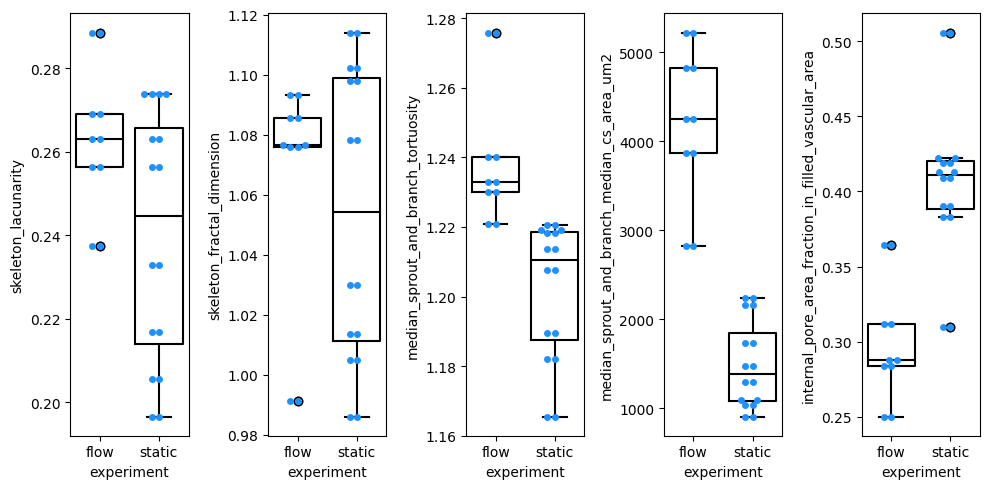

In [8]:
fig, ax = plt.subplots(ncols = 5, figsize=(10,5))
sns.swarmplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_tortuosity", ax=ax[2], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_tortuosity", ax=ax[2], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_median_cs_area_um2", ax=ax[3], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_median_cs_area_um2", ax=ax[3], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], fill=False, color="#000000")

plt.tight_layout()

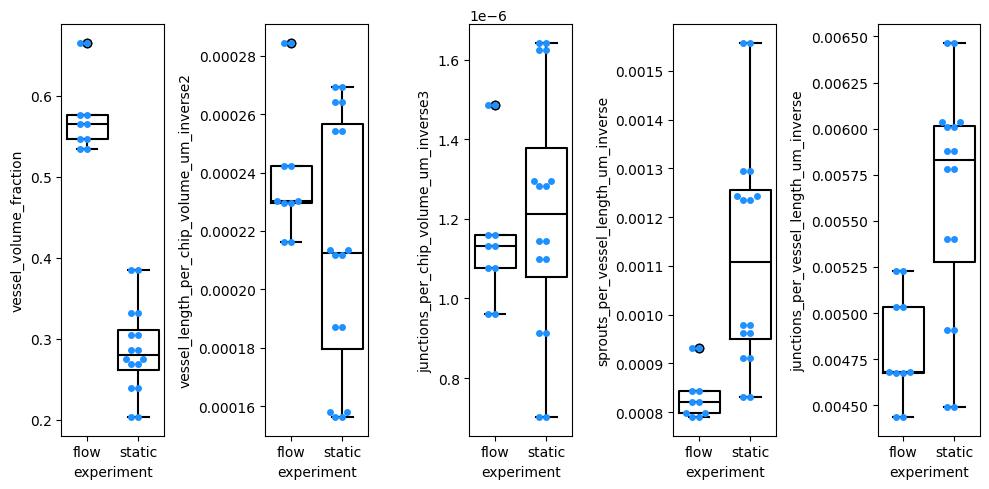

In [9]:
fig, ax = plt.subplots(ncols = 5, figsize=(10,5))
sns.swarmplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], fill=False, color="#000000")

plt.tight_layout()

In [10]:
combined.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'vessel_volume_um3', 'vessel_volume_fraction', 'total_vessel_length_um',
       'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_tortuosity',
       'p90_minus_p10_sprout_and_branch_tortuosity',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'total_internal_pore_count',
       'internal_pore_area_fraction_in_filled_vascular_area',
       'median_internal_pore_area_um2', 'p90_minus_p10_internal_pore_area_um2',
       'median_internal_pore_max_inscribed_